In [63]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
# from python_files import TLM_tests as TT
from Python_files import ETLM as ETLMC
# from Python_files import LETLM as LETLMC
# from Python_files import IETLM as IETLMC
torch.set_default_dtype(torch.float64)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 14400/14400 [00:00<00:00, 22382.87it/s]


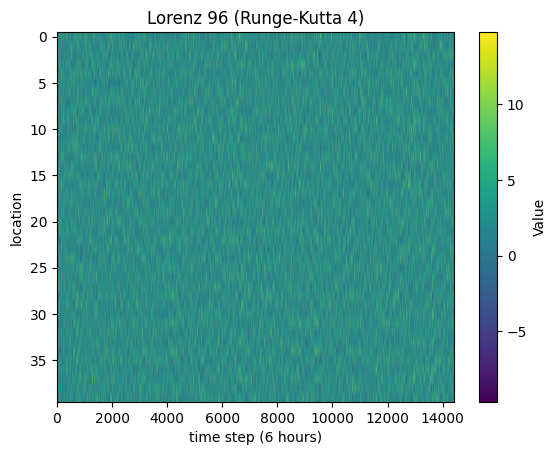

In [12]:
# We will now run the model using Runge-Kutta 4 time stepping:

#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  

# We now set our initial state vector
x = torch.randn(N)
x_in = [x,False]



trajectory = []
times = []
dust_mass = []

t = 0.0

for i in tqdm(range(timesteps)):
    # print(i)
    # plt.title(f' Lorenz 96 after time step = {i:.2f}')
    # plt.plot(x_values, x_in[0])
    # plt.legend()
    # # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # # /Users/imilesfine/PhD Work2026/Lorenz_basic
    # plt.clf()



    trajectory.append(x_in[0].clone())  # store current state
    times.append(t)
    
    x_in = TST.run_model(x_in, model, model_parameters)
    t += dt


trajectory = torch.stack(trajectory)  # shape: (steps, 2N)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T




plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Lorenz 96 (Runge-Kutta 4)")
plt.show()

100%|██████████| 14400/14400 [01:15<00:00, 190.57it/s]


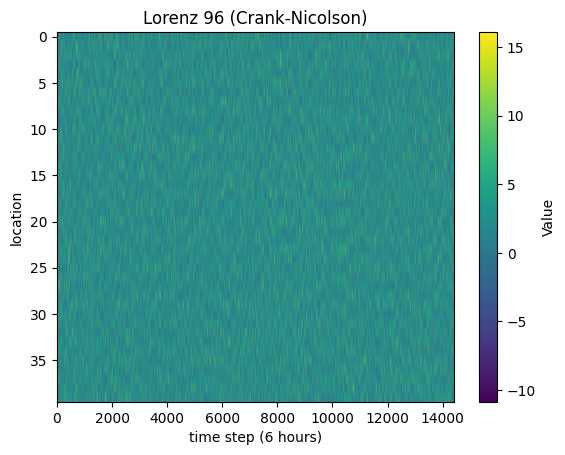

In [26]:
# We will now run the model using Crank-Nicolson time stepping:

#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  

# We now set our initial state vector
x = torch.randn(N,1)
x_in = [x,False]



trajectory = []
times = []
dust_mass = []

t = 0.0

for i in tqdm(range(timesteps)):
    # print(i)
    # plt.title(f' Lorenz 96 after time step = {i:.2f}')
    # plt.plot(x_values, x_in[0])
    # plt.legend()
    # # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # # /Users/imilesfine/PhD Work2026/Lorenz_basic
    # plt.clf()



    trajectory.append(x_in[0].clone().flatten())  # store current state
    # print(trajectory)
    times.append(t)
    
    x_in = TST.run_model(x_in, model, model_parameters)
    t += dt


trajectory = torch.stack(trajectory)  # shape: (steps, 2N)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T




plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Lorenz 96 (Crank-Nicolson)")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.show()

100%|██████████| 14400/14400 [00:00<00:00, 57901.77it/s]


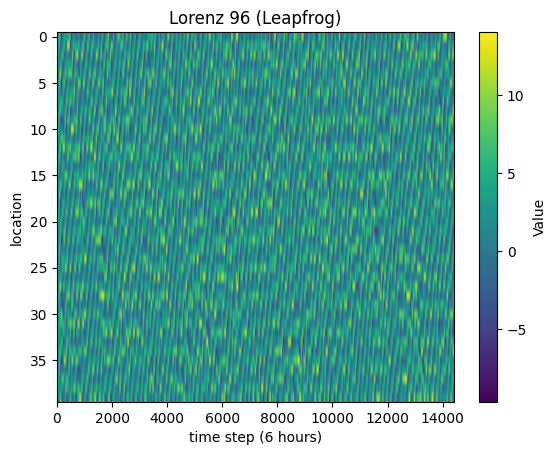

In [25]:
# We will now run the model using Leapfrog time stepping:

#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.01 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.LF_L96
x_values = np.arange(1, N+1)  

# We now set our initial state vector
x = torch.randn(N)
x_in = [x,False]



trajectory = []
times = []
dust_mass = []

t = 0.0

for i in tqdm(range(timesteps)):
    # print(i)
    # plt.title(f' Lorenz 96 after time step = {i:.2f}')
    # plt.plot(x_values, x_in[0])
    # plt.legend()
    # # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # # /Users/imilesfine/PhD Work2026/Lorenz_basic
    # plt.clf()



    trajectory.append(x_in[0].clone())  # store current state
    # Because we are applying an Asselin filter we need to change the previous state.
    if len(trajectory) >= 2:
        trajectory[-2] = x_in[1]
    
    times.append(t)
    
    x_in = TST.run_model(x_in, model, model_parameters)
    t += dt


trajectory = torch.stack(trajectory)  # shape: (steps, 2N)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T




plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Lorenz 96 (Leapfrog)")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.show()

100%|██████████| 150/150 [00:00<00:00, 726.69it/s]


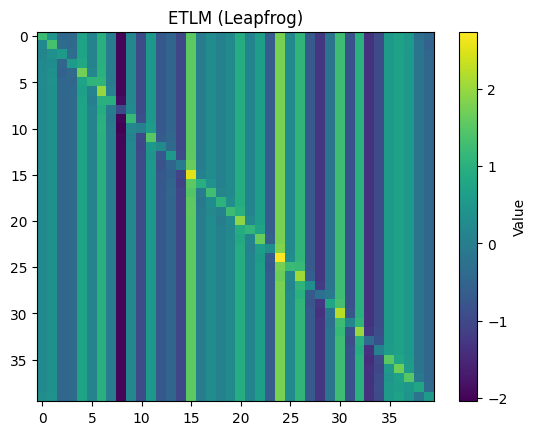

In [76]:
# Now that we have the models running it is now time to test weather the ETLM function works:
# We start by spinning up the model
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.01 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)

spin_up_time = 10000
ensemble_size = 150
model = TST.CN_L96
x_out = ETLMC.spin_up(x, model_parameters, model,spin_up_time)
sd = 10**(-7)

ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

plt.imshow(ETLM,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("ETLM (Leapfrog)")
plt.show()

100%|██████████| 150/150 [00:00<00:00, 726.83it/s]


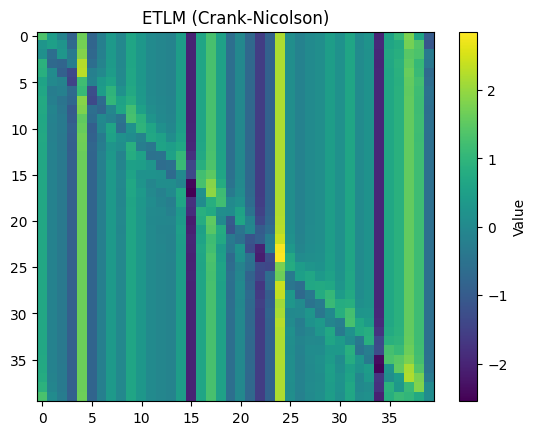

In [71]:
# Now that we have the models running it is now time to test weather the ETLM function works:
# We start by spinning up the model
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)

spin_up_time = 1000
ensemble_size = 150
model = TST.CN_L96
x_out = ETLMC.spin_up(x, model_parameters, model,spin_up_time)
sd = 10**(-7)

ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

plt.imshow(ETLM,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("ETLM (Crank-Nicolson)")
plt.show()

100%|██████████| 150/150 [00:00<00:00, 9377.92it/s]


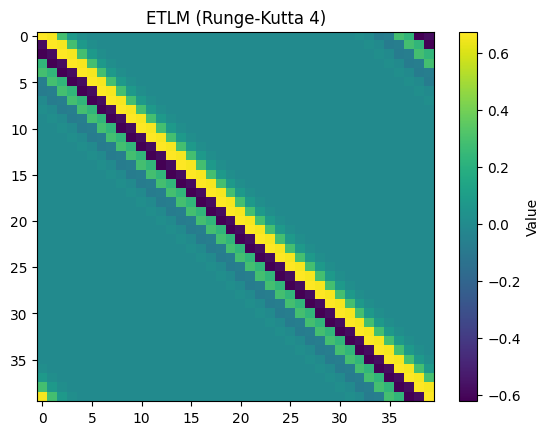

In [73]:
# Now that we have the models running it is now time to test weather the ETLM function works:
# We start by spinning up the model
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)

spin_up_time = 1000
ensemble_size = 150
model = TST.rk4_L96
x_out = ETLMC.spin_up(x, model_parameters, model,spin_up_time)
sd = 10**(-7)

ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

plt.imshow(ETLM,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("ETLM (Runge-Kutta 4)")
plt.show()